In [1]:
%cd ..

/home/boat/proxyISP/pytorch-superpoint


In [2]:
import sys
import yaml
import torch
import pickle
import cv2
import rawpy
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, "../ProxyOpt/")
sys.path.insert(0, "../fast-openISP/")
sys.path.insert(0, "../ProxyOpt/pytorch-msssim/")
from models.model_wrap import SuperPointFrontend_torch

# config_path = "/home/boat/proxyISP/pytorch-superpoint/configs/superpoint_coco_train_heatmap_proxyopt.yaml"
config_path = "/home/boat/proxyISP/pytorch-superpoint/configs/magicpoint_coco_export.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

config.setdefault("model", {}).setdefault("subpixel", {})["enable"] = False

path = config["pretrained"]
assert "170000" in path
nms_dist = 4
nn_thresh = 0.7
conf_thresh = config["model"]["detection_threshold"]
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

magicpoint_gpu_id = "1" if torch.cuda.device_count() > 1 else "0"
magicpoint_device = torch.device(f"cuda:{magicpoint_gpu_id}" if torch.cuda.is_available() else "cpu")
fe = SuperPointFrontend_torch(
        config=config,
        weights_path=path,
        nms_dist=nms_dist,
        conf_thresh=conf_thresh,
        nn_thresh=nn_thresh,
        cuda=False,
        device=magicpoint_device,
)

model:  SuperPointNet_gauss2


In [3]:
from ISP_tools.ProxyISPDataset import ProxyISPDataset, EXPERIMENT_OUTPUT_PATH

train_config_path = "/home/boat/proxyISP/ProxyOpt/train_configs/v16.2-chroma-HumanTunedInitialHype.yaml"

with open(train_config_path, "r") as f:
        yaml_dict = yaml.safe_load(f)

config = yaml_dict["config"]
openisp_config = yaml_dict["openisp_config"]
hyp_setting = yaml_dict["hyp_setting"]
additional_conf = {
    "proxyopt_base_path" : "/home/boat/proxyISP/ProxyOpt"
}
dataset = ProxyISPDataset(config, openisp_config, hyp_setting, additional_conf)

[11-04 21:28:38] ProxyISPDataset.py INFO - Initializing ProxyISPDataset Dataset...
INFO:ISP_tools.ProxyISPDataset:Initializing ProxyISPDataset Dataset...
[11-04 21:28:38] ProxyISPDataset.py INFO - total raw images: 1073
INFO:ISP_tools.ProxyISPDataset:total raw images: 1073


self.config {'experiment_name': 'actual_proxy_v16.2-chroma', 'model_choice': 'proxyopt_unet', 'loss_choice': 'msssim', 'optimizer_choice': 'adam', 'input_type': 'stacked', 'output_domain': 'rgb', 'raw_path': '/mnt/ssd2tb/boat/thesis/s21fe_dataset', 'crop_mode': 'random', 'num_hyperp_to_sample': 50000, 'num_data_to_sample': False, 'img_size': 'dynamic', 'lr': 0.001, 'batch_size': 1, 'epoch': 200000, 'save_iter': 1000, 'save_only_latest': False, 'eval_iter': 10000, 'save_image_iter': 1000, 'lr_scheduler_iter': 13000, 'train_val_ratio': 0.85, 'gradient_accum_step': 1, 'memory_replay_prob': 0, 'memory_replay_buffer': 50, 'device': 'cuda', 'seed': 8888}


[11-04 21:28:39] ProxyISPDataset.py INFO - hyperp length: 50000
INFO:ISP_tools.ProxyISPDataset:hyperp length: 50000
[11-04 21:28:39] ProxyISPDataset.py INFO - num_hyperp x num_image: 53650000
INFO:ISP_tools.ProxyISPDataset:num_hyperp x num_image: 53650000
[11-04 21:28:45] ProxyISPDataset.py INFO - total dataset length: 53650000
INFO:ISP_tools.ProxyISPDataset:total dataset length: 53650000


Executing awb... Done. Elapsed 0.012s
Executing cfa... Done. Elapsed 0.094s
Executing ccm... Done. Elapsed 0.086s
Executing gac... Done. Elapsed 0.046s
Executing bnfcv... Done. Elapsed 0.012s
Executing csc... Done. Elapsed 0.065s
Executing eeh... Done. Elapsed 0.142s
Executing hsc... Done. Elapsed 0.064s
Executing bcc... Done. Elapsed 0.020s
Pipeline elapsed 0.633s
24 24
/home/boat/proxyISP/pytorch-superpoint/logs/PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_train_v16.2-chroma-HumanTunedInitialHype_hpatchesv4_lr0.0005_bothLoss_initialHypeHomoAdaptOnly_gradac102/proxyopt_checkpoints/checkpoint_200.pkl [1, 0, 599, 0.901449978351593, 20, 300, 1, 10, 10, 1, 1, 8, 64, 0, 256, 1613, -591, 2, -134, 1292, -134, 41, -730, 1712]
Executing awb... Done. Elapsed 0.013s
Executing cfa... Done. Elapsed 0.092s
Executing ccm... Done. Elapsed 0.089s
Executing gac... Done. Elapsed 0.047s
Executing bnfcv... Done. Elapsed 0.015s
Executing csc... Done. Elapsed 0.068s
Executing eeh

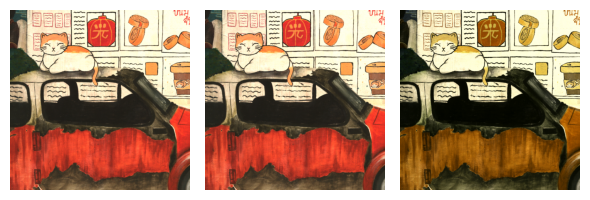

In [31]:
import pickle
import rawpy
import matplotlib.pyplot as plt

raw_path = "/mnt/ssd2tb/boat/thesis/s21fe_hpatches_v4/sl_carforcat/1.dng"

hype_paths = [
    "/home/boat/proxyISP/pytorch-superpoint/logs/PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_train_v16.2-chroma-HumanTunedInitialHype_hpatchesv4_lr0.0005_bothLoss_initialHypeHomoAdaptOnly_gradac102/proxyopt_checkpoints/checkpoint_200.pkl",
    "/home/boat/proxyISP/pytorch-superpoint/logs/PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_train_v16.2-chroma-HumanTunedInitialHype_hpatchesv4_lr0.0005_bothLoss_initialHypeHomoAdaptOnly_gradac102/proxyopt_checkpoints/checkpoint_50000.pkl"
    # add more .pkl paths here if you want
]

bayer = rawpy.imread(raw_path).raw_image
bayer = bayer[540:2460, 1040:2960]  # crop (1920, 1920)

img_original = dataset.process_raw(bayer)

imgBundle = [img_original]

for hype_path in hype_paths:
    with open(hype_path, "rb") as f:
        hyp = pickle.load(f)["proxy_hype"]
        hyp = dataset.denormalize_hyp(hyp)
        print(hype_path, hyp)
    img_optimized = dataset.process_raw(bayer, hyp)
    imgBundle.append(img_optimized)

# visualize
plt.figure(figsize=(6, 3))
for i, img in enumerate(imgBundle):
    plt.subplot(1, len(imgBundle), i + 1)
    plt.imshow(img)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [32]:
import matplotlib.pyplot as plt

def plot_superpoint_keypoints(kp_tensor, image=None, figsize=(8, 8), alpha=0.7):
    """
    Visualize SuperPoint keypoints.

    Args:
        kp_tensor (torch.Tensor or np.ndarray): shape [3, NUM_KP], 
            where each column is [x, y, confidence].
        image (np.ndarray, optional): background image (H, W) or (H, W, 3)
        figsize (tuple): matplotlib figure size.
        alpha (float): transparency of keypoints.

    Example:
        plot_superpoint_keypoints(kp, image)
    """
    import numpy as np
    
    kp = kp_tensor.detach().cpu().numpy() if hasattr(kp_tensor, "detach") else kp_tensor
    x, y, conf = kp[0], kp[1], kp[2]

    plt.figure(figsize=figsize)
    
    if image is not None:
        if image.ndim == 2:
            plt.imshow(image, cmap='gray', vmin = 0, vmax = 1)
        else:
            plt.imshow(image, vmin = 0, vmax = 1)
    else:
        plt.gca().invert_yaxis()  # if no image, flip Y to match image coordinates
    
    plt.scatter(x, y, s=30 * conf, c='lime', edgecolors='red', alpha=alpha)
    plt.title(f"SuperPoint Keypoints (N={len(x)})")
    plt.axis('off')
    plt.show()


In [33]:
imgBundleProcessed = []

sizer = np.array([240, 320]) # from magicpoint_repeatability_heatmap_proxyopt.yaml

for image in imgBundle:
    image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    # s = max(sizer / image.shape[:2])
    # image = image[:int(sizer[0]/s),:int(sizer[1]/s)]
    image = cv2.resize(image, (sizer[1], sizer[0]),
                             interpolation=cv2.INTER_AREA)
    image = image.astype('float32') / 255.0
    
    if image.ndim == 2:
        image = image[np.newaxis, :,:]
    imgTensor = torch.tensor(image)
    imgBundleProcessed.append(imgTensor)
    
  

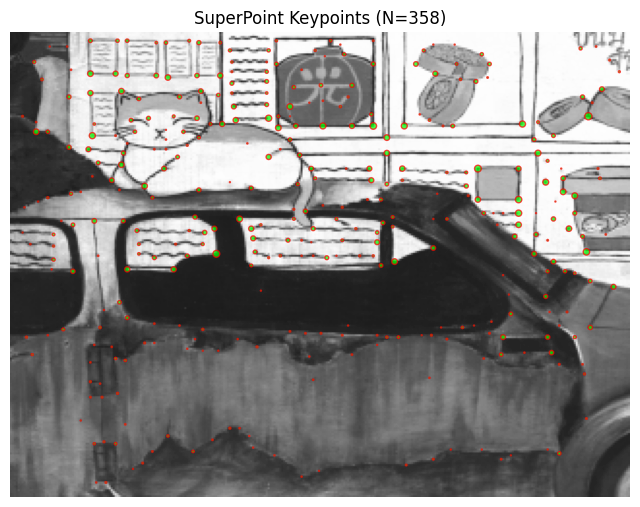

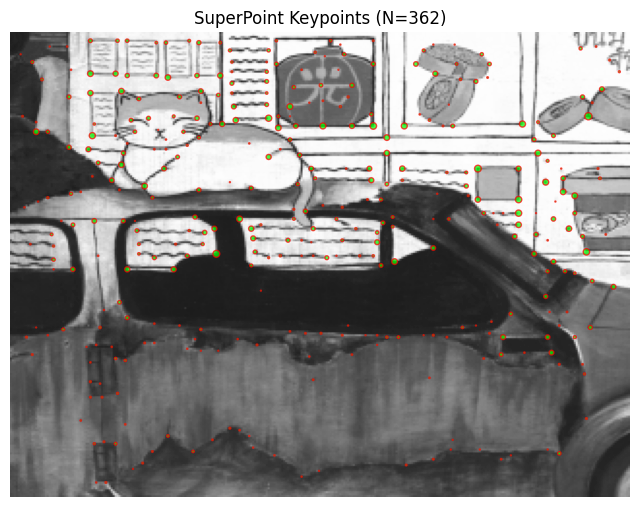

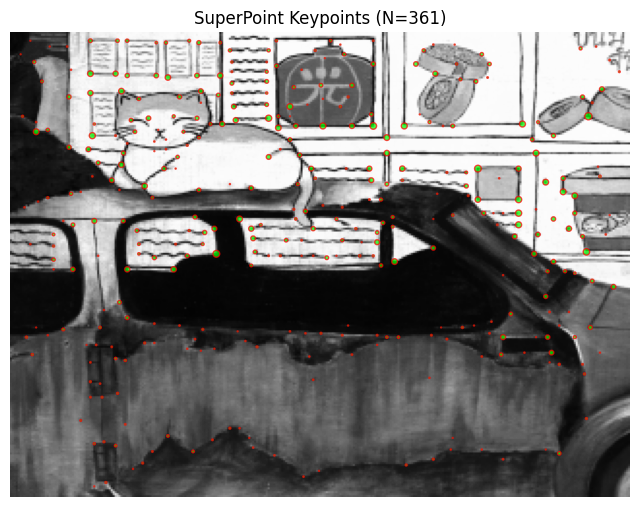

In [34]:
for image in imgBundleProcessed:
    image = image[None, :, :]
    pts, pts_desc, dense_desc, heatmap = fe.run(image)
    plot_superpoint_keypoints(pts[0], image[0][0])

In [35]:
kp_online = np.load("temp_log/homoadapt_pnts_online.npy")
kp_online = np.swapaxes(kp_online, 1, 0)

def plot_superpoint_keypoints_dual(kp1, kp2=None, image=None, figsize=(8, 8), alpha=0.7):
    """
    Visualize one or two sets of SuperPoint keypoints on the same image.

    Args:
        kp1 (torch.Tensor or np.ndarray): shape [3, N1]
        kp2 (torch.Tensor or np.ndarray, optional): shape [3, N2]
        image (np.ndarray, optional): background image (H, W) or (H, W, 3)
        figsize (tuple): figure size
        alpha (float): transparency for keypoints
    """
    # Convert to numpy
    def to_np(t):
        return t.detach().cpu().numpy() if hasattr(t, "detach") else t

    kp1 = to_np(kp1)
    x1, y1, c1 = kp1[0], kp1[1], kp1[2]

    if kp2 is not None:
        kp2 = to_np(kp2)
        x2, y2, c2 = kp2[0], kp2[1], kp2[2]

    plt.figure(figsize=figsize)
    
    # Show image
    if image is not None:
        if image.ndim == 2:
            plt.imshow(image, cmap='gray', vmin=0, vmax=1)
        else:
            plt.imshow(image, vmin=0, vmax=1)
    else:
        plt.gca().invert_yaxis()

    # Plot first keypoint set (green)
    plt.scatter(x1, y1, s=30 * c1, c='lime', edgecolors='red', alpha=alpha, label='Keypoints 1')

    # Plot second keypoint set (optional, orange)
    if kp2 is not None:
        plt.scatter(x2, y2, s=30 * c2, c='cyan', edgecolors='blue', alpha=alpha, label='Keypoints 2')

    plt.title(f"SuperPoint Keypoints (Set1={len(x1)}" + (f", Set2={len(x2)})" if kp2 is not None else ")"))
    plt.axis('off')
    plt.legend()
    plt.show()

plot_superpoint_keypoints_dual(pts[0], kp_online, image[0][0])

FileNotFoundError: [Errno 2] No such file or directory: 'temp_log/homoadapt_pnts_online.npy'